## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Load CSV File

In [2]:
df = pd.read_csv("Instagram_Analytics.csv")

## 3. Read Dataset

1) First 5 rows

In [3]:
df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


2. Last 5 rows

In [4]:
df.tail()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
29994,IG0029995,5,brand,10739,carousel,Travel,Reels Feed,0,2024-12-18 10:00:00,2024-12-18,...,1,2,5,1564,2493,0.0032,124,127,8,low
29995,IG0029996,3,brand,10018,image,Beauty,Hashtags,0,2025-05-05 15:00:00,2025-05-05,...,2,1,7,2042,2492,0.0209,310,114,12,low
29996,IG0029997,18,creator,7486,image,Photography,Explore,1,2025-05-26 10:00:00,2025-05-26,...,10,16,59,5887,7528,0.0558,223,115,4,high
29997,IG0029998,6,creator,10034,carousel,Technology,Explore,1,2025-08-02 19:00:00,2025-08-02,...,3,0,19,5372,6312,0.0333,978,124,4,medium
29998,IG0029999,9,creator,6916,image,Technology,Explore,1,2025-04-15 20:00:00,2025-04-15,...,1,1,5,4019,5678,0.0100,272,126,11,low


## 4. Basic Information

1. Shape

In [6]:
df.shape

(29999, 23)

2. Columns

In [7]:
df.columns

Index(['post_id', 'account_id', 'account_type', 'follower_count', 'media_type',
       'content_category', 'traffic_source', 'has_call_to_action',
       'post_datetime', 'post_date', 'post_hour', 'day_of_week', 'likes',
       'comments', 'shares', 'saves', 'reach', 'impressions',
       'engagement_rate', 'followers_gained', 'caption_length',
       'hashtags_count', 'performance_bucket_label'],
      dtype='object')

3. Info

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares

4. Describre

In [9]:
df.describe()

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,10.567819,10278.305477,0.348778,11.499417,287.653588,8.521917,14.426614,42.517284,6272.475449,8466.952498,0.042107,502.152805,120.081169,7.987933
std,5.763952,6691.862669,0.476592,6.900587,317.647682,10.116505,16.420899,47.808844,4985.877059,6825.900355,0.024095,290.364038,11.009108,2.828130
min,1.000000,3083.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268.000000,327.000000,0.000000,0.000000,70.000000,0.000000
25%,6.000000,5824.000000,0.000000,6.000000,104.000000,3.000000,5.000000,15.000000,3058.000000,4102.000000,0.024000,251.000000,113.000000,6.000000
50%,11.000000,9044.000000,0.000000,12.000000,199.000000,6.000000,10.000000,29.000000,4913.000000,6595.000000,0.040600,501.000000,120.000000,8.000000
75%,16.000000,10739.000000,1.000000,17.000000,363.000000,11.000000,19.000000,54.000000,7863.000000,10620.500000,0.057000,755.000000,127.000000,10.000000
max,20.000000,31095.000000,1.000000,23.000000,10632.000000,339.000000,516.000000,1542.000000,73339.000000,105203.000000,0.271000,1000.000000,166.000000,21.000000


## 5. Missing Values

In [10]:
df.isnull().sum()

,0
post_id,0
account_id,0
account_type,0
follower_count,0
media_type,0
content_category,0
traffic_source,0
has_call_to_action,0
post_datetime,0
post_date,0


## 6. Duplicate Values

In [11]:
df.duplicated().sum()


np.int64(0)

## 7. Convert Date Column

In [14]:
if 'post_date' not in df.columns and df.index.name == 'post_date':
    df = df.reset_index()

df['post_date'] = pd.to_datetime(df['post_date'])
df = df.sort_values('post_date')

# Set index
df.set_index('post_date', inplace=True)
print(df.head())

              post_id  account_id account_type  follower_count media_type  \
post_date                                                                   
2024-11-19  IG0027732          10        brand            4542      image   
2024-11-19  IG0028181           9      creator            6916      image   
2024-11-19  IG0015119          12      creator           13798      image   
2024-11-19  IG0028570          12      creator           13798   carousel   
2024-11-19  IG0020617          16        brand            9696      image   

           content_category traffic_source  has_call_to_action  \
post_date                                                        
2024-11-19      Photography        Profile                   0   
2024-11-19             Food      Home Feed                   1   
2024-11-19          Fashion        Explore                   0   
2024-11-19       Technology       Hashtags                   0   
2024-11-19          Fashion      Home Feed                   0  

## 8. Time Series Data

In [16]:
ts = df['likes']
print(ts.head())

post_date
2024-11-19    510
2024-11-19    461
2024-11-19    195
2024-11-19    764
2024-11-19     92
Name: likes, dtype: int64


## 9. ARIMA Model

In [17]:
model_arima = ARIMA(ts, order=(1,1,1))   # (p,d,q)
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

# Forecast
forecast_arima = model_arima_fit.forecast(steps=10)
print("ARIMA Forecast:\n", forecast_arima)

                               SARIMAX Results                                
Dep. Variable:                  likes   No. Observations:                29999
Model:                 ARIMA(1, 1, 1)   Log Likelihood             -215386.851
Date:                Wed, 01 Apr 2026   AIC                         430779.701
Time:                        05:24:38   BIC                         430804.628
Sample:                             0   HQIC                        430787.699
                              - 29999                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0018      0.005      0.328      0.743      -0.009       0.012
ma.L1         -0.9998      0.000  -6274.352      0.000      -1.000      -0.999
sigma2      1.009e+05    128.404    785.635      0.0

## 10. SARIMA Model

In [18]:
model_sarima = SARIMAX(ts,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,7))   # weekly seasonality

model_sarima_fit = model_sarima.fit()

print(model_sarima_fit.summary())

# Forecast
forecast_sarima = model_sarima_fit.forecast(steps=10)
print("SARIMA Forecast:\n", forecast_sarima)

                                     SARIMAX Results                                     
Dep. Variable:                             likes   No. Observations:                29999
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood             -217978.259
Date:                           Wed, 01 Apr 2026   AIC                         435966.518
Time:                                   05:26:29   BIC                         436008.061
Sample:                                        0   HQIC                        435979.848
                                         - 29999                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2133      0.004    -48.671      0.000      -0.222      -0.205
ma.L1         -1.0000      0.001   -813.995

## 11. Data Visualization (Graphs)

📊 Graph 1: Likes Over Time

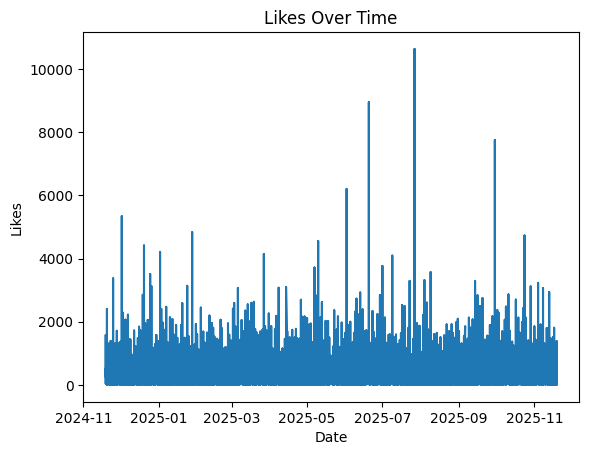

In [19]:
plt.figure()
plt.plot(ts)
plt.title("Likes Over Time")
plt.xlabel("Date")
plt.ylabel("Likes")
plt.show()

📊 Graph 2: Engagement Rate Trend

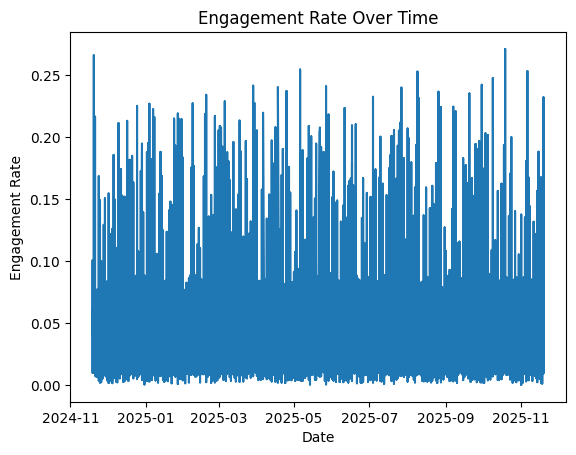

In [20]:
plt.figure()
plt.plot(df['engagement_rate'])
plt.title("Engagement Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Engagement Rate")
plt.show()

## 12. (Bonus) Resampling (Better Time Series)

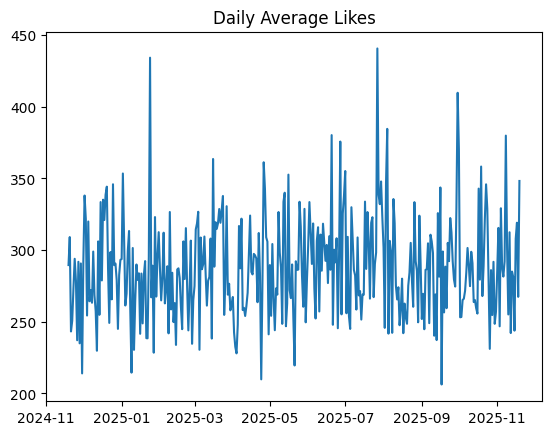

In [21]:
# Daily average likes
daily_likes = ts.resample('D').mean()

plt.figure()
plt.plot(daily_likes)
plt.title("Daily Average Likes")
plt.show()